In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import petals

N_test = 256
N=256

In [ ]:
X, y = petals.training_data(N=N, seed=37)
print(X.shape, y.shape)

X2 = X.flatten()[:, np.newaxis]

@np.vectorize
def is_odd(n):
    return int(n % 2 != 0)

@np.vectorize
def is_prime(n):
    if n < 2:
        return 0
    for i in range(2, int(np.sqrt(n)) + 1):
        if n % i == 0:
            return 0
    return 1

def augment(X):
    features = np.hstack([X, is_odd(X), X * is_odd(X)])
    bias = np.ones((X.shape[0], 1), dtype=X.dtype)
    return np.hstack([features, bias])

X2 = augment(X2)

In [155]:
X2[:10, :]

array([[4, 0, 0, 1],
       [5, 1, 5, 1],
       [4, 0, 0, 1],
       [5, 1, 5, 1],
       [6, 0, 0, 1],
       [3, 1, 3, 1],
       [4, 0, 0, 1],
       [4, 0, 0, 1],
       [3, 1, 3, 1],
       [6, 0, 0, 1]])

In [156]:
y2 = y.repeat(5)
print(X2.shape, y2.shape)

solution, residuals, rank, singular_values = np.linalg.lstsq(X2, y2, rcond=None)
solution, residuals, rank, singular_values

(1280, 4) (1280,)


(array([-0.0506753 , -0.97775392,  0.96431885,  4.43265294]),
 array([11959.99428987]),
 4,
 array([159.44876627,  65.35053386,  17.58733606,   5.92319746]))

miscalibration: -1.132


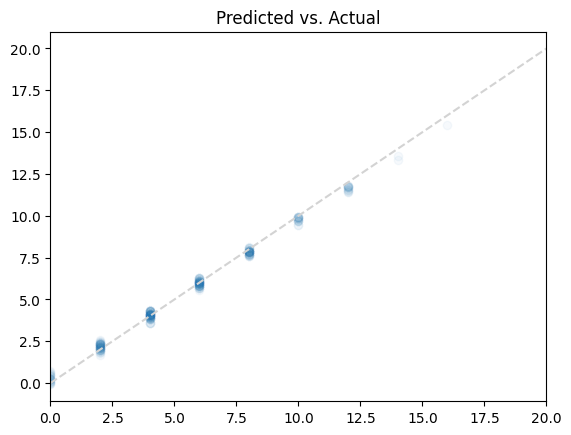

In [162]:


y_pred = []
y_true = []
for i in range(N_test):
    row = X[i]
    row[:, np.newaxis]
    X_test = augment(row[:, np.newaxis])
    
    y_pred.append( (X_test[:, :-1] @ solution[:-1]).sum() )
    y_true.append( y[i] )

y_pred = np.array(y_pred)
y_true = np.array(y_true)

offset = y_pred.mean() - y_true.mean()
print(f"miscalibration: {offset:0.3f}")
y_pred = y_pred - offset

plt.title("Predicted vs. Actual")
#plt.ylim(0, 20)
plt.xlim(0, 20)
plt.scatter(y_true, y_pred, alpha=10/N_test)
plt.plot(
    [0, 20],
    [0, 20],
    linestyle="--",
    color="lightgray"
);